In [1]:
#  import python libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer


In [2]:
#  data loading

df = pd.read_excel("data.xlsx")

df.head()

,Temperature_C,Pressure_bar,FlowRate_mL_min,Dosage_g,AdsorptionCapacity_mmol_g
0,53.77,1.23,118.76,0.95,1.419
1,65.15,1.78,155.48,0.56,1.013
2,34.84,5.55,56.63,0.90,2.632
3,34.92,6.30,252.36,0.51,2.207
4,61.26,7.28,135.06,0.81,2.634


In [3]:
#  check information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature_C              100 non-null    float64
 1   Pressure_bar               100 non-null    float64
 2   FlowRate_mL_min            100 non-null    float64
 3   Dosage_g                   100 non-null    float64
 4   AdsorptionCapacity_mmol_g  100 non-null    float64
dtypes: float64(5)
memory usage: 4.0 KB


In [4]:
#  check shape of data

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100
Number of columns: 5


In [5]:
#  check columns

df.columns

Index(['Temperature_C', 'Pressure_bar', 'FlowRate_mL_min', 'Dosage_g',
       'AdsorptionCapacity_mmol_g'],
      dtype='object')

In [6]:
#  check missing values

df.isnull().sum()

Temperature_C                0
Pressure_bar                 0
FlowRate_mL_min              0
Dosage_g                     0
AdsorptionCapacity_mmol_g    0
dtype: int64

In [7]:
#  check duplicate values

print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


In [8]:
#  statistical summary
df.describe()

,Temperature_C,Pressure_bar,FlowRate_mL_min,Dosage_g,AdsorptionCapacity_mmol_g
count,100.00000,100.000000,100.000000,100.000000,100.000000
mean,48.07220,5.469800,176.399000,1.513400,2.641600
std,14.05804,2.439425,65.810393,0.618647,0.672893
min,25.16000,1.050000,50.420000,0.510000,1.013000
25%,35.63500,3.385000,117.632500,0.980000,2.141750
50%,45.64500,5.865000,171.910000,1.430000,2.652500
75%,61.55250,7.402500,228.822500,2.162500,3.116000
max,69.89000,9.890000,299.820000,2.470000,4.058000


In [9]:
#  Analyze the target variable

target = "AdsorptionCapacity_mmol_g"

target_count = df[target].describe()

target_count

count    100.000000
mean       2.641600
std        0.672893
min        1.013000
25%        2.141750
50%        2.652500
75%        3.116000
max        4.058000
Name: AdsorptionCapacity_mmol_g, dtype: float64

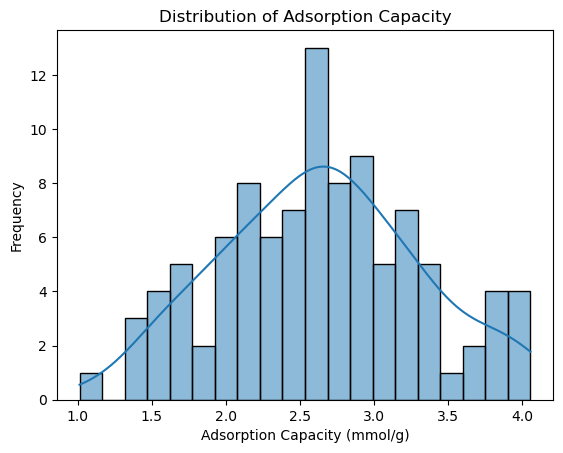

In [10]:
#  Analyze Adsorption Capacity distribution

sns.histplot(
    data=df,
    x="AdsorptionCapacity_mmol_g",
    bins=20,
    kde=True
)

plt.title("Distribution of Adsorption Capacity")
plt.xlabel("Adsorption Capacity (mmol/g)")
plt.ylabel("Frequency")

plt.show()

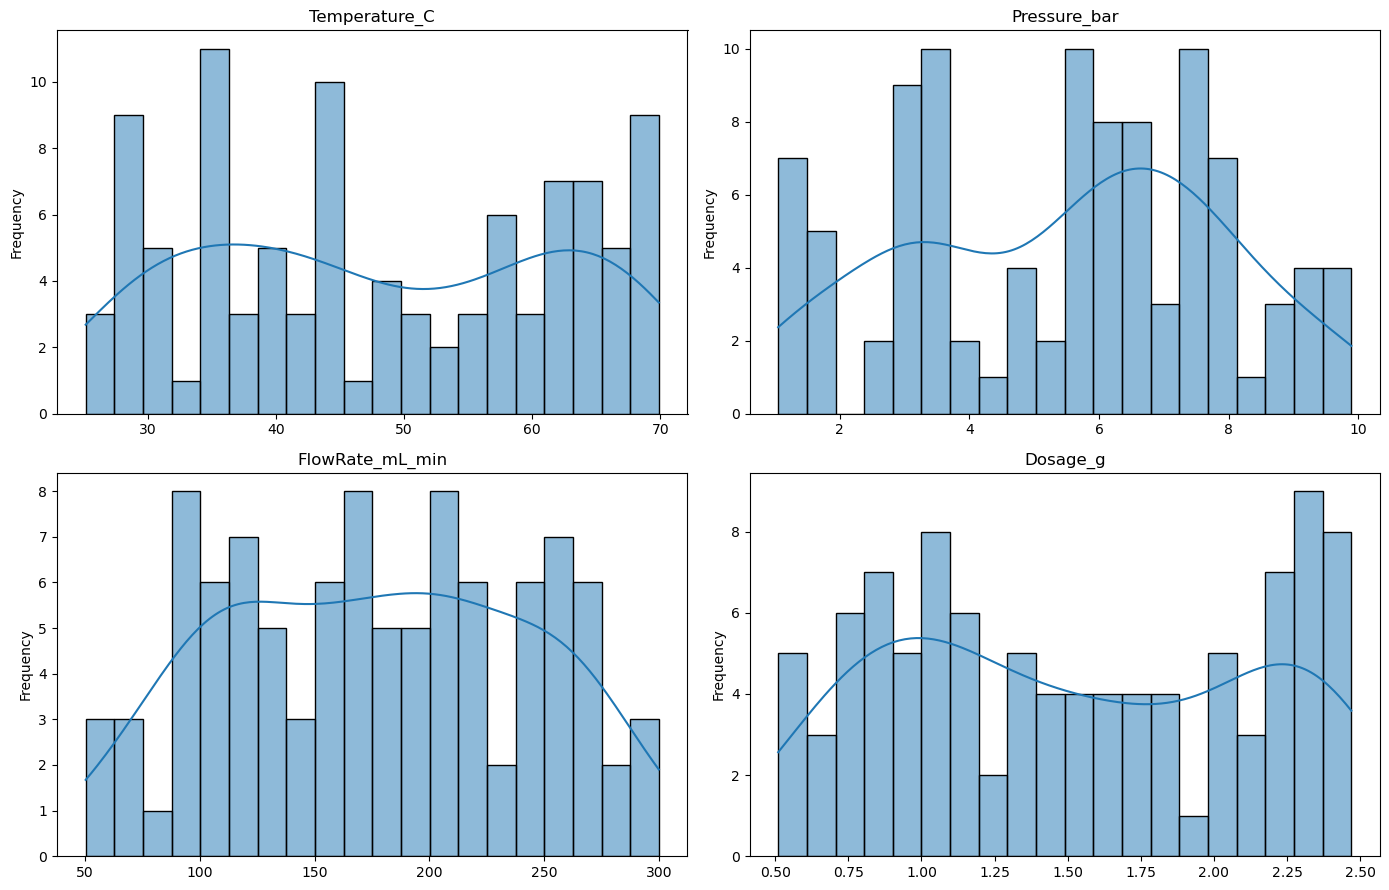

In [11]:
#  Analyze the features data

features = [
    "Temperature_C",
    "Pressure_bar",
    "FlowRate_mL_min",
    "Dosage_g"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, features):

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "01_feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
#  Analyze the numerical features

df[features].describe()

,Temperature_C,Pressure_bar,FlowRate_mL_min,Dosage_g
count,100.00000,100.000000,100.000000,100.000000
mean,48.07220,5.469800,176.399000,1.513400
std,14.05804,2.439425,65.810393,0.618647
min,25.16000,1.050000,50.420000,0.510000
25%,35.63500,3.385000,117.632500,0.980000
50%,45.64500,5.865000,171.910000,1.430000
75%,61.55250,7.402500,228.822500,2.162500
max,69.89000,9.890000,299.820000,2.470000


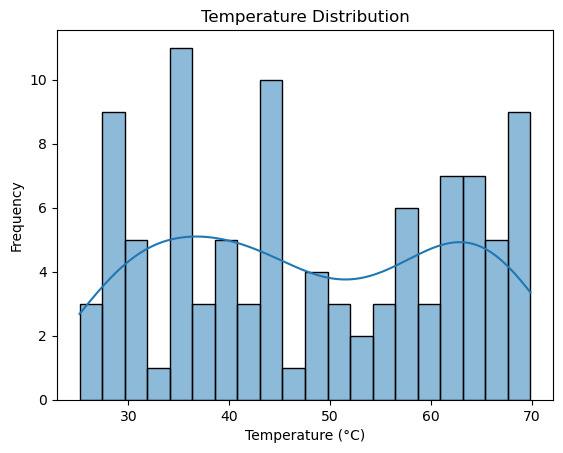

In [13]:
#  Temperature analysis

sns.histplot(
    data=df,
    x="Temperature_C",
    bins=20,
    kde=True
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

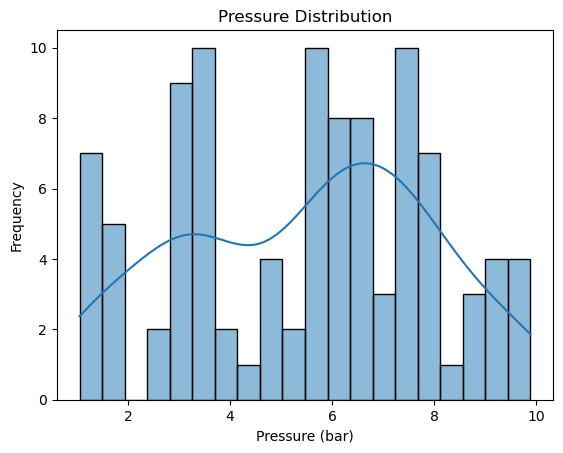

In [14]:
#  Pressure analysis

sns.histplot(
    data=df,
    x="Pressure_bar",
    bins=20,
    kde=True
)

plt.title("Pressure Distribution")
plt.xlabel("Pressure (bar)")
plt.ylabel("Frequency")

plt.show()

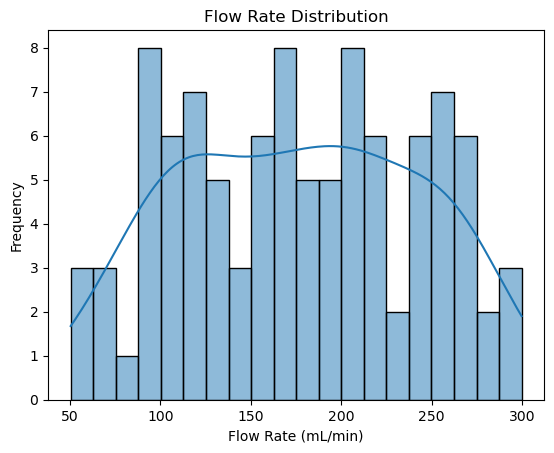

In [15]:
#  Flow Rate analysis

sns.histplot(
    data=df,
    x="FlowRate_mL_min",
    bins=20,
    kde=True
)

plt.title("Flow Rate Distribution")
plt.xlabel("Flow Rate (mL/min)")
plt.ylabel("Frequency")

plt.show()

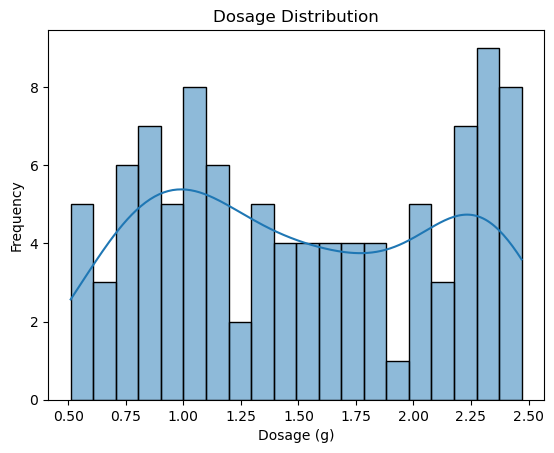

In [16]:
#  Dosage analysis

sns.histplot(
    data=df,
    x="Dosage_g",
    bins=20,
    kde=True
)

plt.title("Dosage Distribution")
plt.xlabel("Dosage (g)")
plt.ylabel("Frequency")

plt.show()

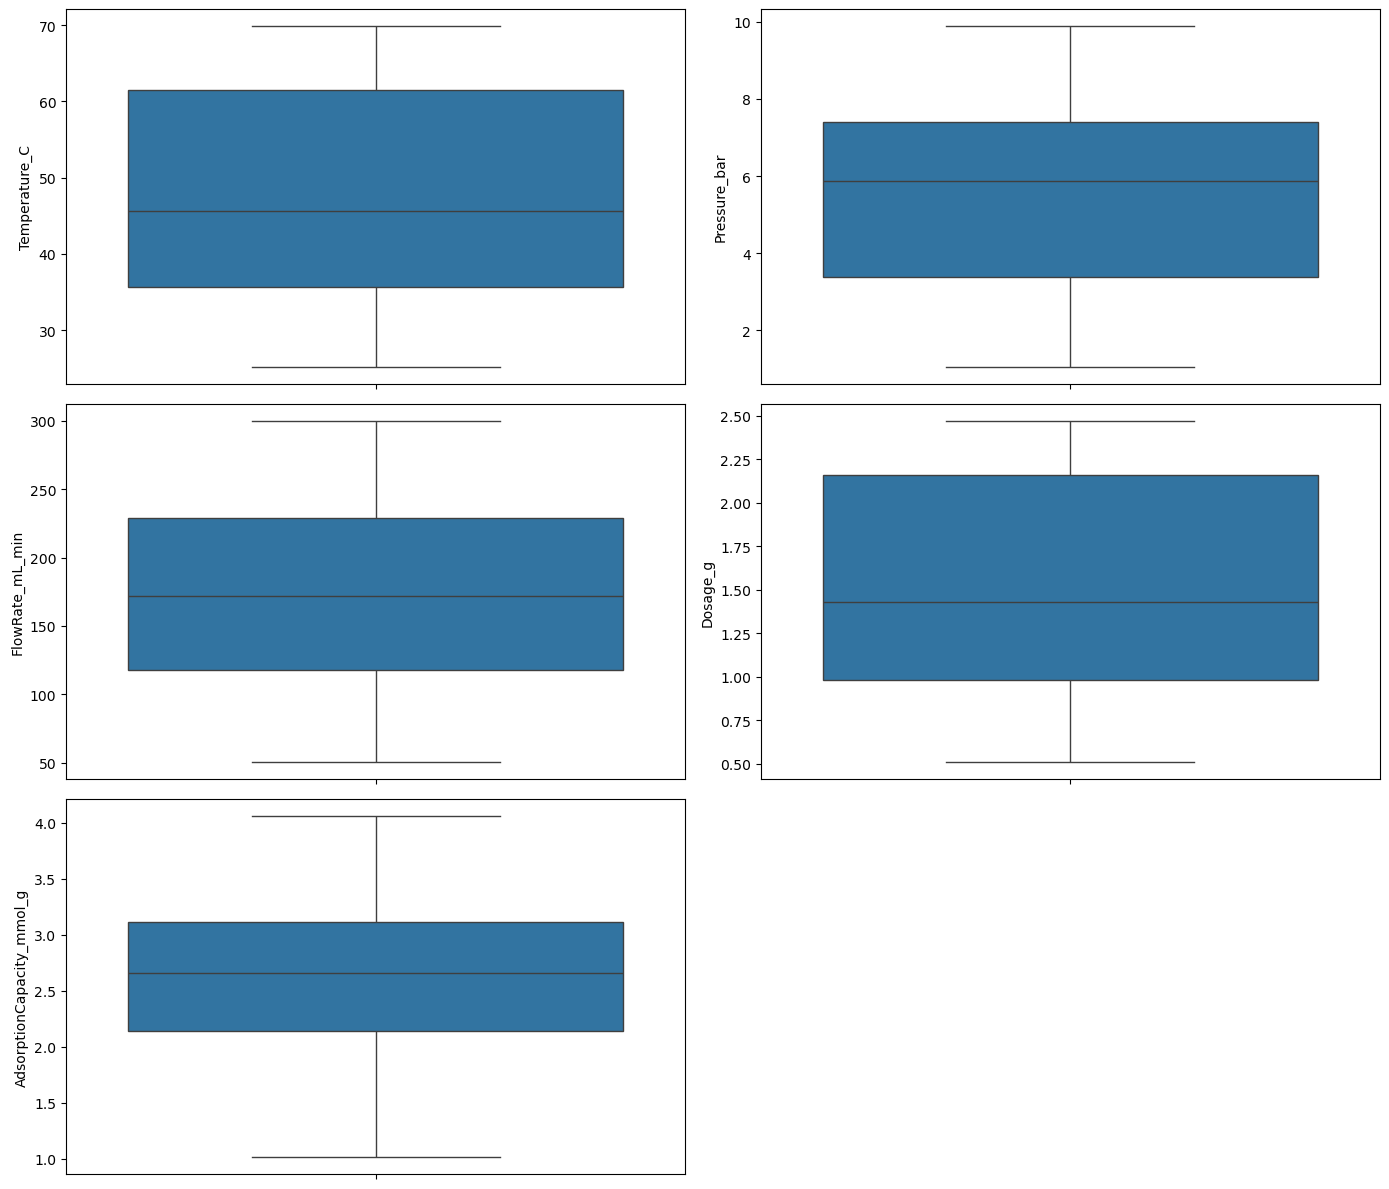

In [17]:
#  Outliers detection - Box plots

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

sns.boxplot(
    ax=axes[0, 0],
    data=df,
    y="Temperature_C"
)

sns.boxplot(
    ax=axes[0, 1],
    data=df,
    y="Pressure_bar"
)

sns.boxplot(
    ax=axes[1, 0],
    data=df,
    y="FlowRate_mL_min"
)

sns.boxplot(
    ax=axes[1, 1],
    data=df,
    y="Dosage_g"
)

sns.boxplot(
    ax=axes[2, 0],
    data=df,
    y="AdsorptionCapacity_mmol_g"
)

# Remove empty subplot
fig.delaxes(axes[2, 1])

plt.tight_layout()

plt.savefig(
    "02_check_for_outlier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
#  Find outliers using IQR method

for column in df.columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(
        column,
        "=> Number of outliers:",
        len(outliers)
    )

Temperature_C => Number of outliers: 0
Pressure_bar => Number of outliers: 0
FlowRate_mL_min => Number of outliers: 0
Dosage_g => Number of outliers: 0
AdsorptionCapacity_mmol_g => Number of outliers: 0


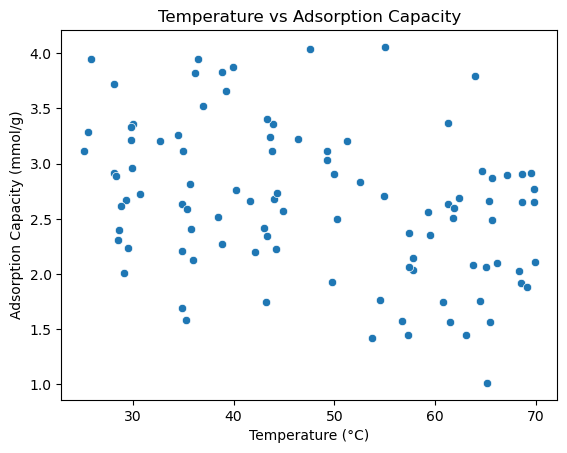

In [19]:
#  Analyze relationship between Temperature and Adsorption Capacity

sns.scatterplot(
    data=df,
    x="Temperature_C",
    y="AdsorptionCapacity_mmol_g"
)

plt.title(
    "Temperature vs Adsorption Capacity"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Adsorption Capacity (mmol/g)")

plt.show()

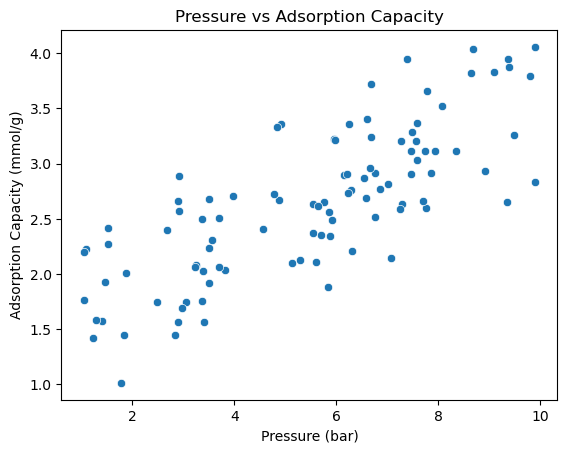

In [20]:
#  Analyze relationship between Pressure and Adsorption Capacity

sns.scatterplot(
    data=df,
    x="Pressure_bar",
    y="AdsorptionCapacity_mmol_g"
)

plt.title(
    "Pressure vs Adsorption Capacity"
)

plt.xlabel("Pressure (bar)")
plt.ylabel("Adsorption Capacity (mmol/g)")

plt.show()

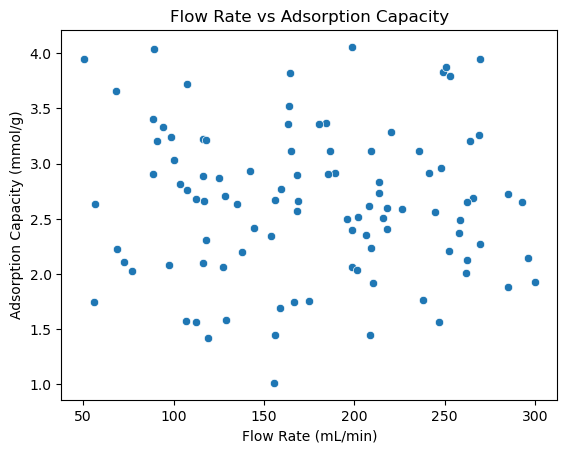

In [21]:
#  Analyze relationship between Flow Rate and Adsorption Capacity

sns.scatterplot(
    data=df,
    x="FlowRate_mL_min",
    y="AdsorptionCapacity_mmol_g"
)

plt.title(
    "Flow Rate vs Adsorption Capacity"
)

plt.xlabel("Flow Rate (mL/min)")
plt.ylabel("Adsorption Capacity (mmol/g)")

plt.show()

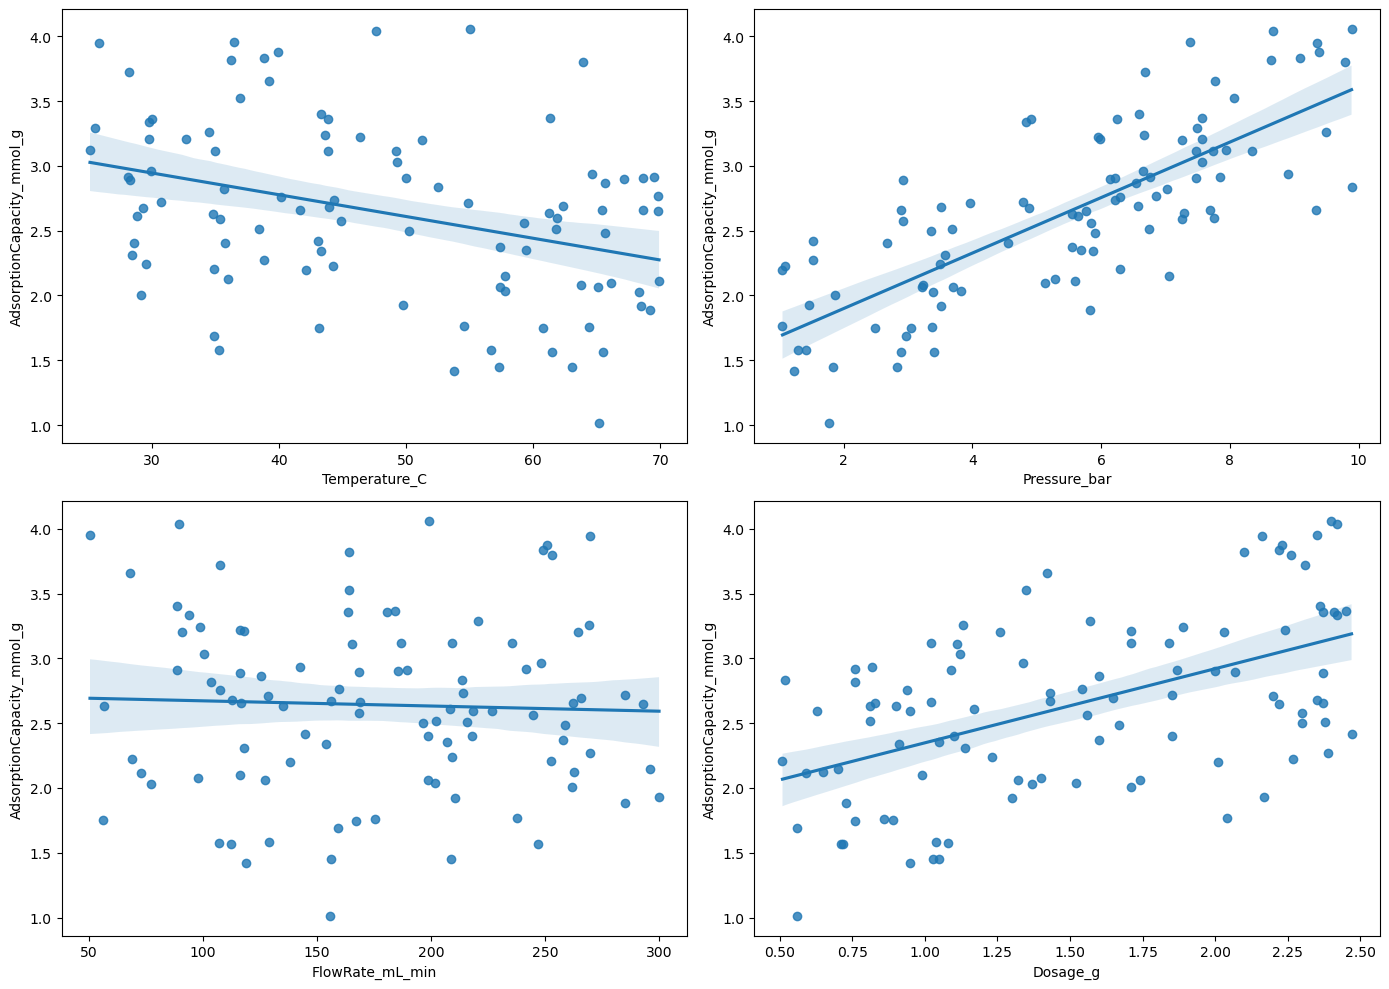

In [22]:
#  Regression plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.regplot(
    data=df,
    x="Temperature_C",
    y="AdsorptionCapacity_mmol_g",
    ax=axes[0, 0]
)

sns.regplot(
    data=df,
    x="Pressure_bar",
    y="AdsorptionCapacity_mmol_g",
    ax=axes[0, 1]
)

sns.regplot(
    data=df,
    x="FlowRate_mL_min",
    y="AdsorptionCapacity_mmol_g",
    ax=axes[1, 0]
)

sns.regplot(
    data=df,
    x="Dosage_g",
    y="AdsorptionCapacity_mmol_g",
    ax=axes[1, 1]
)

plt.tight_layout()

plt.savefig(
    "03_features_vs_target.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

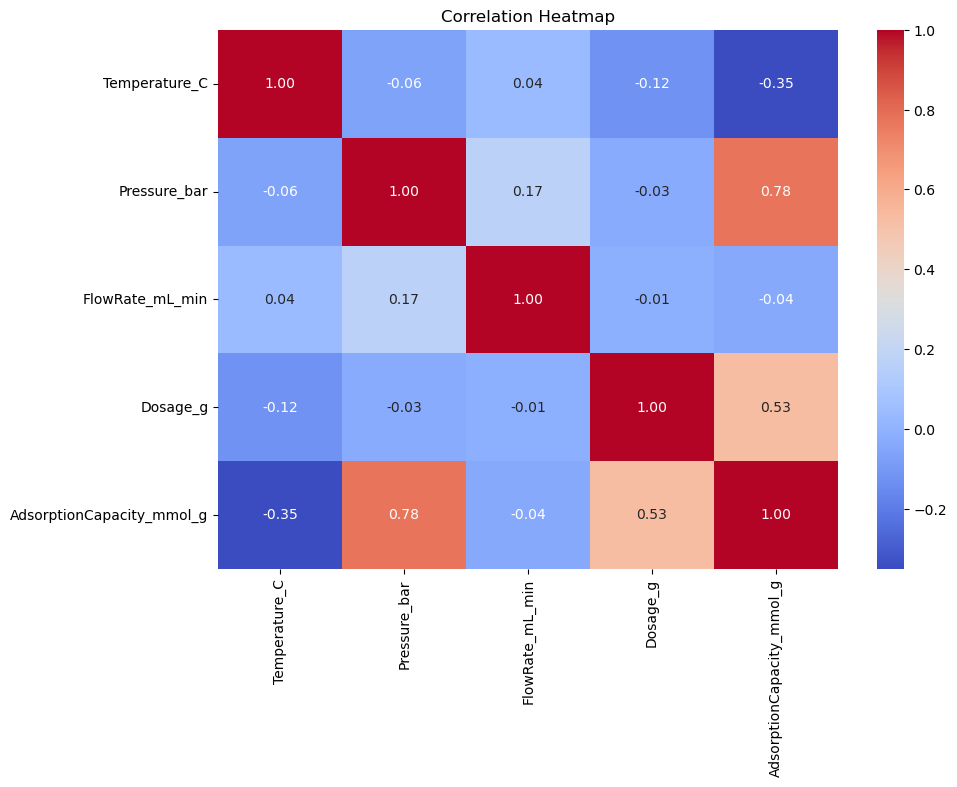

In [23]:
#  Find Correlation heatmap

correl_matrix = df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correl_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "04_heatmap_image.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
#  Correlation with target

df.corr()["AdsorptionCapacity_mmol_g"].sort_values(
    ascending=False
)

AdsorptionCapacity_mmol_g    1.000000
Pressure_bar                 0.775950
Dosage_g                     0.525894
FlowRate_mL_min             -0.039133
Temperature_C               -0.351056
Name: AdsorptionCapacity_mmol_g, dtype: float64

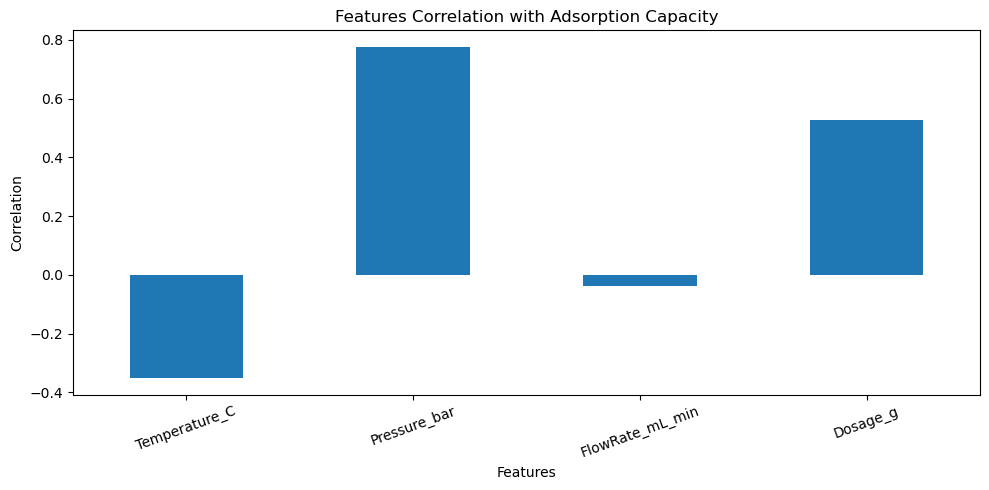

In [25]:
#  Analyze correlation with target

target_corr = df.corr()["AdsorptionCapacity_mmol_g"].drop(
    "AdsorptionCapacity_mmol_g"
)

target_corr.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Features Correlation with Adsorption Capacity"
)

plt.xlabel("Features")
plt.ylabel("Correlation")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "05_target_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

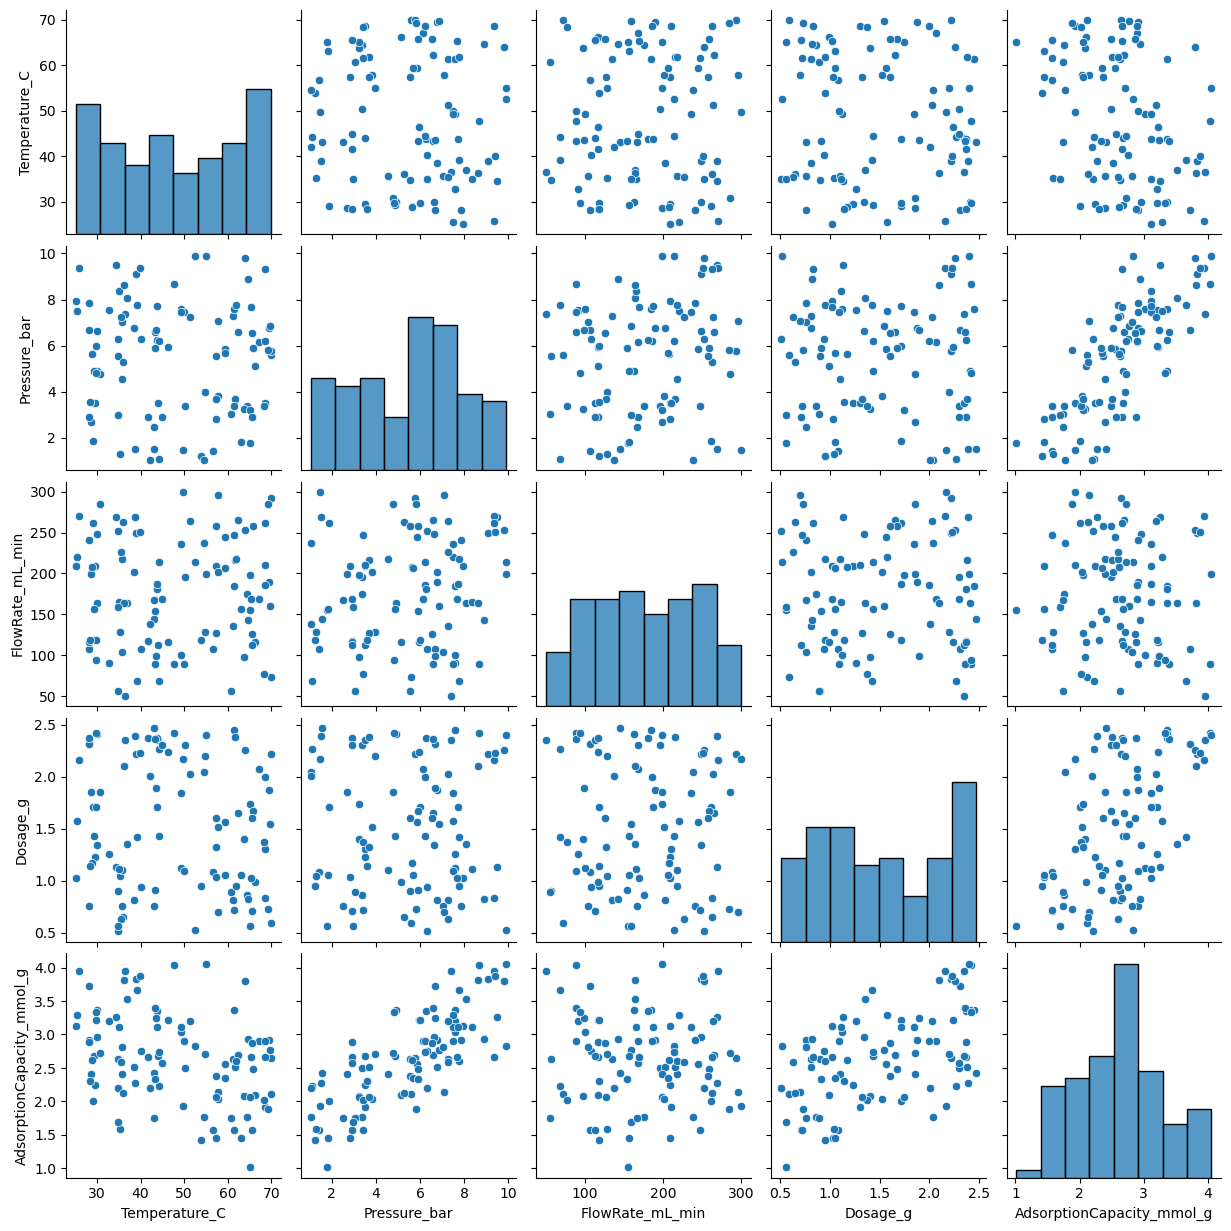

In [26]:
#  Pairplot

sns.pairplot(
    df,
    diag_kind="hist"
)

plt.savefig(
    "06_pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
#  Analyze skewness

skewness = df.skew()

print("Skewness of each feature:")
print(skewness)

Skewness of each feature:
Temperature_C                0.039432
Pressure_bar                -0.149952
FlowRate_mL_min             -0.000824
Dosage_g                     0.086886
AdsorptionCapacity_mmol_g    0.075401
dtype: float64


In [28]:
#  Analyze kurtosis

kurtosis = df.kurtosis()

print("Kurtosis of each feature:")
print(kurtosis)

Kurtosis of each feature:
Temperature_C               -1.391823
Pressure_bar                -0.969167
FlowRate_mL_min             -1.059537
Dosage_g                    -1.402984
AdsorptionCapacity_mmol_g   -0.411325
dtype: float64


In [29]:
#  Check minimum and maximum values

for column in df.columns:

    print(
        column,
        "=> Min:",
        df[column].min(),
        "Max:",
        df[column].max()
    )

Temperature_C => Min: 25.16 Max: 69.89
Pressure_bar => Min: 1.05 Max: 9.89
FlowRate_mL_min => Min: 50.42 Max: 299.82
Dosage_g => Min: 0.51 Max: 2.47
AdsorptionCapacity_mmol_g => Min: 1.013 Max: 4.058


In [30]:
#  Final EDA summary

print("----------- EDA SUMMARY -----------")

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nCorrelation with target:")
print(
    df.corr()["AdsorptionCapacity_mmol_g"]
    .sort_values(ascending=False)
)

print("-----------------------------------")

----------- EDA SUMMARY -----------
Total rows: 100
Total columns: 5

Missing values:
Temperature_C                0
Pressure_bar                 0
FlowRate_mL_min              0
Dosage_g                     0
AdsorptionCapacity_mmol_g    0
dtype: int64

Duplicate rows:
0

Correlation with target:
AdsorptionCapacity_mmol_g    1.000000
Pressure_bar                 0.775950
Dosage_g                     0.525894
FlowRate_mL_min             -0.039133
Temperature_C               -0.351056
Name: AdsorptionCapacity_mmol_g, dtype: float64
-----------------------------------


In [31]:
#  After Analyzing the data we got

#  Dataset contains 100 records and 5 numerical features.

#  Temperature_C
#  Temperature is one of the experimental input variables.

#  Pressure_bar
#  Pressure is another experimental input variable.

#  FlowRate_mL_min
#  Flow rate represents the flow condition of the experiment.

#  Dosage_g
#  Dosage represents the amount of material used in the experiment.

#  AdsorptionCapacity_mmol_g
#  Adsorption Capacity is the target variable that we want to analyze
#  and later predict using machine learning.

#  The correlation heatmap helps us identify which input variables
#  have stronger or weaker relationships with Adsorption Capacity.

#  Scatter plots help us understand the relationship between each
#  experimental feature and the target variable.

#  Boxplots are used to identify possible outliers.

#  Histograms are used to understand the distribution of each variable.